# Organizing Boreas' Data

In the last notebook, we cracked open Boreas' data files and learned how to work with CSVs using pandas. By the end, we had 70 of them — one for every U.S. national park — each holding years of temperature data.

Boreas is a penguin on a mission: he wants the *coldest* park. To find it, we need to compare all 70 parks at once. But opening 70 files one at a time and manually tracking the minimums would be very tedious. Through the power of python and open-source software packages, we can make our lives MUCH easier.

There's a better way. We're going to forge all 70 CSVs into a single, structured file called a [NetCDF](https://www.unidata.ucar.edu/software/netcdf/). Once we have that, a tool called [xarray](https://docs.xarray.dev/en/stable/) can find the coldest park across all locations and all time in just a few lines of code.

In this notebook we'll:

- Decode the park name, latitude, and longitude hidden inside each filename
- Understand what a gridded dataset is and why it's useful for this kind of data
- Build an `xarray.Dataset` by combining all 70 DataFrames onto a lat/lon/time grid
- Save it as a NetCDF file that the next notebook will use to locate Boreas

In [1]:
import os
import pandas as pd
import numpy as np
import xarray as xr

files = os.listdir('data')

## Decoding the Filenames

Before we can combine everything, we need to know *where* each park is. Latitude and longitude aren't stored inside the CSV data itself — but whoever organized this drive was thoughtful: that information is encoded right in the filenames.

Let's look at one.

In [2]:
file = files[0]
file

'Yellowstone-National-Park_249.411484_44.423691_.csv'

There's a clear pattern: `ParkName_Longitude_Latitude_.csv`. We can crack it apart using [string splitting](https://docs.python.org/3/library/stdtypes.html#str.split).

In [3]:
file.split('_')

['Yellowstone-National-Park', '249.411484', '44.423691', '.csv']

Splitting on `_` gives us a list: park name at index 0, longitude at index 1, latitude at index 2. We can pull each piece out by position.

In [4]:
split = file.split('_')
name = split[0]
lon = split[1]
lat = split[2]

print(f'{name} is at ({lon}, {lat})')

Yellowstone-National-Park is at (249.411484, 44.423691)


## Building a Gridded Dataset with xarray

Now that we can extract each park's location from its filename, we need a way to hold all 70 parks' data in one place — organized by location and time.

The key idea is a **grid**: imagine a spreadsheet where the rows are latitudes, the columns are longitudes, and each cell holds a time series of temperatures. That's exactly what [xarray](https://docs.xarray.dev/en/stable/) is built for.

The payoff: once everything is on that grid, finding the coldest park across all locations and all 2+ years of data will take a single line. We'll get there in the next notebook.

For now, let's walk through the approach on three pretend parks so the steps are clear before you apply it to all 70 real ones.

The recipe:
- Tag each DataFrame with its park name, latitude, and longitude
- Stack all DataFrames into one big table with `pd.concat`
- Create an empty `xarray.Dataset` on a lat/lon/time grid
- Loop through each park and fill the right grid cell with its temperatures

In [5]:
df1 = pd.DataFrame({
    "time": pd.date_range("2020-01-01", periods=3, freq="D"),
    "temperature": [10, 1, 33],
})
df1['park'] = "Yellowstone"
df1['lat'] = 44.6
df1['lon'] = -110.5

df2 = pd.DataFrame({
    "time": pd.date_range("2020-01-01", periods=3, freq="D"),
    "temperature": [30, 5, 25],
})
df2["park"] = "Grand Canyon"
df2["lat"] = 36.1
df2["lon"] = -112.1

df3 = pd.DataFrame({
    "time": pd.date_range("2020-01-01", periods=3, freq="D"),
    "temperature": [10, 20, 30],
})
df3["park"] = "Denali"
df3["lat"] = 63.1
df3["lon"] = -151.0

display(df1)
display(df2)
display(df3)

,time,temperature,park,lat,lon
0,2020-01-01,10,Yellowstone,44.6,-110.5
1,2020-01-02,1,Yellowstone,44.6,-110.5
2,2020-01-03,33,Yellowstone,44.6,-110.5


,time,temperature,park,lat,lon
0,2020-01-01,30,Grand Canyon,36.1,-112.1
1,2020-01-02,5,Grand Canyon,36.1,-112.1
2,2020-01-03,25,Grand Canyon,36.1,-112.1


,time,temperature,park,lat,lon
0,2020-01-01,10,Denali,63.1,-151.0
1,2020-01-02,20,Denali,63.1,-151.0
2,2020-01-03,30,Denali,63.1,-151.0


All three parks are now in one table. But notice it's still flat — just rows of observations. The next step is to give it *structure* by placing each park onto a geographic grid.

In [6]:
df_all = pd.concat([df1, df2, df3], ignore_index=True)
df_all

,time,temperature,park,lat,lon
0,2020-01-01,10,Yellowstone,44.6,-110.5
1,2020-01-02,1,Yellowstone,44.6,-110.5
2,2020-01-03,33,Yellowstone,44.6,-110.5
3,2020-01-01,30,Grand Canyon,36.1,-112.1
4,2020-01-02,5,Grand Canyon,36.1,-112.1
5,2020-01-03,25,Grand Canyon,36.1,-112.1
6,2020-01-01,10,Denali,63.1,-151.0
7,2020-01-02,20,Denali,63.1,-151.0
8,2020-01-03,30,Denali,63.1,-151.0


To build the xarray grid we first define its axes: a range of latitudes, a range of longitudes, and a sequence of times. For this toy example we'll use a coarse grid that covers the continental US and Alaska — big enough to hold our three parks.

In [7]:
lats = np.arange(30, 75, 5)
lons = np.arange(-160, -95, 5)
times = pd.date_range("2020-01-01", periods=3)

Next we create an empty `xarray.Dataset` shaped to that grid. Think of it as reserving a 3D block of slots — one per (lat, lon, time) combination — pre-filled with `NaN` (not a number) as a placeholder. We also reserve a 2D slot per (lat, lon) for the park name, since a location only needs one name regardless of time.

In [8]:
ds = xr.Dataset(
    {
        "temperature": (("lat", "lon", "time"), np.full((len(lats), len(lons), len(times)), np.nan)),
        "park_name": (("lat", "lon"), np.full((len(lats), len(lons)), "", dtype=object)),
    },
    coords={"lat": lats, "lon": lons, "time": times},
)
ds

<xarray.Dataset> Size: 4kB
Dimensions:      (lat: 9, lon: 13, time: 3)
Coordinates:
  * lat          (lat) int64 72B 30 35 40 45 50 55 60 65 70
  * lon          (lon) int64 104B -160 -155 -150 -145 ... -115 -110 -105 -100
  * time         (time) datetime64[ns] 24B 2020-01-01 2020-01-02 2020-01-03
Data variables:
    temperature  (lat, lon, time) float64 3kB nan nan nan nan ... nan nan nan
    park_name    (lat, lon) object 936B '' '' '' '' '' '' ... '' '' '' '' '' ''

Now we fill the grid. We use [pandas groupby](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.groupby.html) to loop over each park in the combined table. For each one, xarray's `sel(..., method="nearest")` snaps the park's actual coordinates to the closest grid point, and we write the temperatures in. Any grid cell with no nearby park stays `NaN`.

In [9]:
for (park, lat, lon), group in df_all.groupby(["park", "lat", "lon"]):
    # Select nearest grid cell
    sel = ds.sel(lat=lat, lon=lon, method="nearest")
    lat_sel = sel.lat.values.item()
    lon_sel = sel.lon.values.item()

    temps = group["temperature"].values
    ds["temperature"].loc[dict(lat=lat_sel, lon=lon_sel)] = temps
    ds["park_name"].loc[dict(lat=lat_sel, lon=lon_sel)] = park

There it is — three parks, one dataset. The `NaN` values are grid cells with no park nearby; that's expected. Notice the shape: lat × lon × time, with park names sitting on the lat/lon layer.

In [10]:
ds

<xarray.Dataset> Size: 4kB
Dimensions:      (lat: 9, lon: 13, time: 3)
Coordinates:
  * lat          (lat) int64 72B 30 35 40 45 50 55 60 65 70
  * lon          (lon) int64 104B -160 -155 -150 -145 ... -115 -110 -105 -100
  * time         (time) datetime64[ns] 24B 2020-01-01 2020-01-02 2020-01-03
Data variables:
    temperature  (lat, lon, time) float64 3kB nan nan nan nan ... nan nan nan
    park_name    (lat, lon) object 936B '' '' '' '' '' '' ... '' '' '' '' '' ''

Quick sanity check: let's plot the temperature at the first time step. You should see three dots — one near Yellowstone in the Rockies, one near the Grand Canyon in the Southwest, and one way up near Denali in Alaska. We'll make much more compelling maps in the next notebook; this is just to confirm the data landed in the right places.

In [11]:
vmin, vmax = ds.temperature.min(), ds.temperature.max()

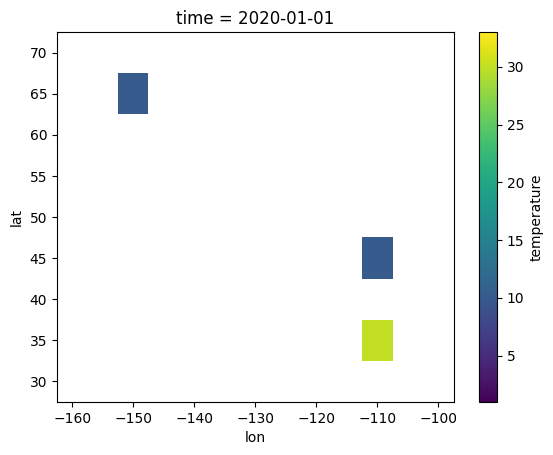

In [12]:
ds.isel(time=0)['temperature'].plot(vmin=vmin, vmax=vmax)

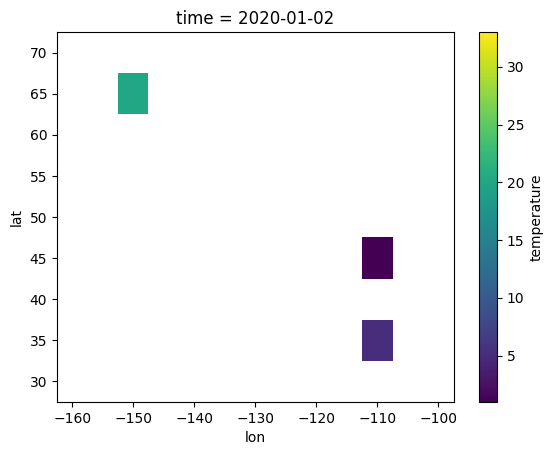

In [13]:
ds.isel(time=1)['temperature'].plot(vmin=vmin, vmax=vmax)

One method call and the entire dataset is on disk. In the next notebook we'll load the real version of this file — built from all 70 parks — and use it to narrow down where Boreas went.

In [14]:
ds.to_netcdf("example.nc")

## Now You Try: Build the Real Dataset

You've seen the whole recipe on a toy example. Now it's time to run it on the actual data — all 70 parks, two years of observations, one NetCDF file.

This is the file that the next notebook will use to find the coldest park on Earth and, with it, Boreas. The steps are identical to what you just did; the only difference is scale. Fill in the missing pieces — shell code and the pre-defined grid are provided.

If you get stuck, a pre-made solution and a pre-built dataset are available so you won't be blocked for the next notebook.

In [15]:
longitudes = np.arange(200, 331, 2.5)
latitudes = np.arange(75, 14, -2.5)
times = pd.date_range(start="2013-01-01", end="2014-12-31 18:00:00", freq="6h")

In [ ]:
all_dfs = []
for file in files:
    # read the CSV from the data/ directory into a DataFrame

    # split the filename on '_' to get [park_name, longitude, latitude, '.csv']
    # add park, lon, and lat as new columns on the DataFrame

    # append the DataFrame to all_dfs

In [ ]:
# below is the gridded dataset to fill in
ds = xr.Dataset(
    {
        "temperature": (("lat", "lon", "time"), np.full((len(latitudes), len(longitudes), len(times)), np.nan)),
        "park_name": (("lat", "lon"), np.full((len(latitudes), len(longitudes)), "", dtype=object)),
    },
    coords={"lat": latitudes, "lon": longitudes, "time": times},
)
ds

In [ ]:
# stack all 70 DataFrames from all_dfs into one flat table using pd.concat

In [ ]:
for (park, lat, lon), group in df_all.groupby(["park", "lat", "lon"]):
    # find the nearest grid cell using ds.sel with method="nearest"

    # extract lat_sel and lon_sel from the selection

    # grab the temperature values — note: the column is called 'air', not 'temperature'

    # assign temps to ds["temperature"] at the right lat/lon

    # assign the park name to ds["park_name"] at the right lat/lon

In [ ]:
ds

In [ ]:
ds.to_netcdf("national_park_temperatures.nc")

In [ ]:
ds.isel(time=0)['temperature'].plot()